# GNN: Forward Pass Verification

Implements `GNNModel` (two-layer GraphSAGE) and `train_gnn`. Verifies correct output shape and no NaNs for all three graph types before any training runs. Training runs are in Tasks 4.4, 4.5, 4.6.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import json
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import config
from src.models import HARModel, GNNModel, compute_har_features, prepare_har_arrays
from src.train import set_seeds, train_gnn, train_gnn_corr_ablation
from src.graphs import build_correlation_graph, build_sector_graph, make_pyg_data

In [2]:
# Load all data needed by the GNN verification cells and the HAR scatter comparison
weekly_rv = pd.read_parquet(Path(config.DATA_RAW_DIR) / 'weekly_rv.parquet')
target    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'target.parquet')
splits    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'splits.parquet')
tickers   = target.columns.tolist()

# HAR features and fitted model — used in Plot 5 scatter comparison
rv_1w, rv_4w, rv_13w = compute_har_features(weekly_rv)
X_train, y_train, _, _, _ = prepare_har_arrays(
    rv_1w, rv_4w, rv_13w, target, splits, 'train'
)
har = HARModel()
har.fit(X_train, y_train)

# Reconstruct 3D feature tensor
meta          = json.load(open(Path(config.DATA_FEATURES_DIR) / 'features_meta.json'))
feature_names = meta['feature_names']
feat_df       = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'features.parquet')
feat_df['week'] = pd.to_datetime(feat_df['week'])
feat_df = feat_df[feat_df['week'].isin(target.index)].copy()
ticker_order    = {t: i for i, t in enumerate(tickers)}
feat_df['_ord'] = feat_df['ticker'].map(ticker_order)
feat_df = feat_df.sort_values(['week', '_ord']).drop(columns='_ord')

n_weeks  = target.shape[0]
n_stocks = target.shape[1]
n_feats  = len(feature_names)

features_3d = feat_df[feature_names].values.reshape(n_weeks, n_stocks, n_feats)
target_arr  = target.values

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

assert features_3d.shape == (n_weeks, n_stocks, n_feats)
assert target_arr.shape  == (n_weeks, n_stocks)
print(f'features_3d: {features_3d.shape}  target_arr: {target_arr.shape}')
print(f'tickers: {len(tickers)}  n_feats: {n_feats}  device: {device}')
print('HAR model fitted on training data.')

features_3d: (572, 50, 10)  target_arr: (572, 50)
tickers: 50  n_feats: 10  device: cuda
HAR model fitted on training data.


In [3]:
log_returns    = pd.read_parquet(Path(config.DATA_RAW_DIR) / "log_returns.parquet")
sector_history = json.load(open(Path(config.DATA_RAW_DIR) / "sector_history.json"))
granger_df     = pd.read_parquet(Path(config.DATA_GRAPHS_DIR) / "granger_edges.parquet")

granger_edge_index = torch.tensor(
    [granger_df["src"].values, granger_df["dst"].values], dtype=torch.long
)
print(f"log_returns:     {log_returns.shape}")
print(f"Granger edges:   {granger_edge_index.shape[1]:,} directed edges")
print(f"sector_history:  {len(sector_history)} tickers")

log_returns:     (2764, 50)
Granger edges:   1,443 directed edges
sector_history:  50 tickers


C:\Users\Rylan Wade\AppData\Local\Temp\ipykernel_24160\3870147225.py:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  granger_edge_index = torch.tensor(


In [4]:
# Instantiate GNNModel and print architecture
set_seeds()
gnn_test = GNNModel(in_channels=n_feats).to(device)
print(gnn_test)
print(f"\nTrainable parameters: {sum(p.numel() for p in gnn_test.parameters()):,}")

GNNModel(
  (conv1): SAGEConv(10, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 9,665


In [5]:
# Build edge indices for one mid-train sample week
sample_pos  = 200
sample_week = target.index[sample_pos]
print(f"Sample week: {sample_week.date()}  (train position {sample_pos})")

corr_edge_index   = build_correlation_graph(
    log_returns, sample_week, config.CORR_LOOKBACK_DAYS, config.CORR_THRESHOLD
)
sector_edge_index = build_sector_graph(tickers, sample_week.year, sector_history)
# granger_edge_index is static — loaded above, same tensor for all time steps

print(f"\nEdge counts at {sample_week.date()}:")
print(f"  Correlation (θ={config.CORR_THRESHOLD}):  {corr_edge_index.shape[1]:>6,}")
print(f"  Sector ({sample_week.year}):                {sector_edge_index.shape[1]:>6,}")
print(f"  Granger (static):              {granger_edge_index.shape[1]:>6,}")

Sample week: 2018-11-05  (train position 200)

Edge counts at 2018-11-05:
  Correlation (θ=0.3):   1,518
  Sector (2018):                   352
  Granger (static):               1,443


In [6]:
# Forward pass — shape and NaN verification on all three graph types
features_t = torch.tensor(features_3d[sample_pos], dtype=torch.float32).to(device)
target_t   = torch.tensor(target_arr[sample_pos],   dtype=torch.float32).to(device)

gnn_test.eval()
with torch.no_grad():
    out_corr    = gnn_test(features_t, corr_edge_index.to(device))
    out_sector  = gnn_test(features_t, sector_edge_index.to(device))
    out_granger = gnn_test(features_t, granger_edge_index.to(device))

print("Forward pass results:")
for name, out in [("Correlation", out_corr), ("Sector", out_sector), ("Granger", out_granger)]:
    print(f"  {name:12s}  shape={tuple(out.shape)}  NaNs={out.isnan().sum().item()}"
          f"  min={out.min().item():+.4f}  max={out.max().item():+.4f}")

assert not out_corr.isnan().any(),    "NaN in Correlation output"
assert not out_sector.isnan().any(),  "NaN in Sector output"
assert not out_granger.isnan().any(), "NaN in Granger output"
print("\nAll shape and NaN assertions passed.")

Forward pass results:
  Correlation   shape=(50,)  NaNs=0  min=-0.3328  max=+0.0754
  Sector        shape=(50,)  NaNs=0  min=-0.3759  max=+0.0420
  Granger       shape=(50,)  NaNs=0  min=-0.3486  max=+0.0336

All shape and NaN assertions passed.


### Plot 1: Output distributions at random initialization

All three variants operating on the same feature vector and same week.
At random init the predictions should be near zero with similar spread.
Red dashed line = mean actual RV for this week (the scale target).

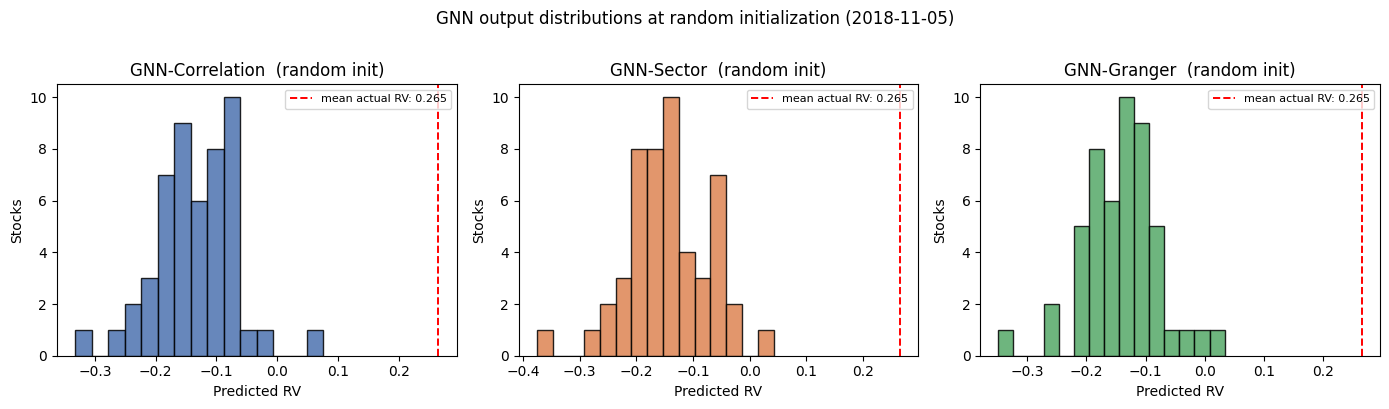

In [7]:
import matplotlib.pyplot as plt

actual_rv    = target_t.cpu().numpy()
mean_actual  = actual_rv.mean()
graph_data   = [
    ("Correlation", out_corr,    "#4C72B0"),
    ("Sector",      out_sector,  "#DD8452"),
    ("Granger",     out_granger, "#55A868"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, out, color) in zip(axes, graph_data):
    vals = out.cpu().numpy()
    ax.hist(vals, bins=15, color=color, edgecolor="k", alpha=0.85)
    ax.axvline(mean_actual, color="red", linestyle="--", linewidth=1.4,
               label=f"mean actual RV: {mean_actual:.3f}")
    ax.set_title(f"GNN-{name}  (random init)")
    ax.set_xlabel("Predicted RV")
    ax.set_ylabel("Stocks")
    ax.legend(fontsize=8)

plt.suptitle(f"GNN output distributions at random initialization ({sample_week.date()})", y=1.01)
plt.tight_layout()
plt.show()

### Plot 2: Edge counts at three characteristic dates

Shows how the correlation graph density shifts across market regimes.
Sector and Granger counts are constant (same bars at every date).

calm     (2017-06-30):  corr=606  sector=352  granger=1,443
covid    (2020-03-13):  corr=2,362  sector=352  granger=1,443
recent   (2023-06-30):  corr=1,904  sector=352  granger=1,443


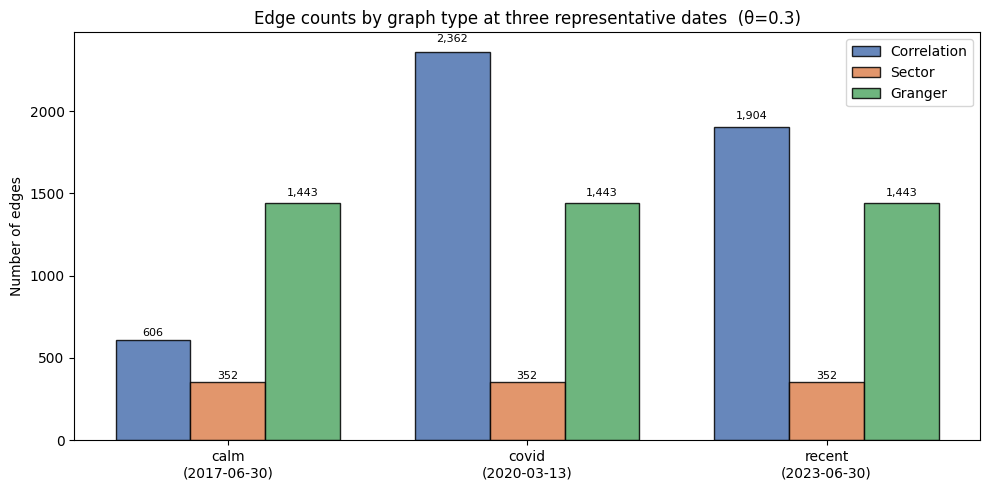

In [8]:
sample_dates = {k: pd.Timestamp(v) for k, v in config.CORR_SAMPLE_DATES.items()}

edge_counts = {}
for label, date in sample_dates.items():
    ei = build_correlation_graph(log_returns, date, config.CORR_LOOKBACK_DAYS, config.CORR_THRESHOLD)
    se = build_sector_graph(tickers, date.year, sector_history)
    edge_counts[label] = {
        "Correlation": ei.shape[1],
        "Sector":      se.shape[1],
        "Granger":     granger_edge_index.shape[1],
    }
    print(f"{label:8s} ({date.date()}):  corr={ei.shape[1]:,}  "
          f"sector={se.shape[1]:,}  granger={granger_edge_index.shape[1]:,}")

labels      = list(sample_dates.keys())
graph_types = ["Correlation", "Sector", "Granger"]
colors      = ["#4C72B0", "#DD8452", "#55A868"]
x           = np.arange(len(labels))
width       = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (gtype, color) in enumerate(zip(graph_types, colors)):
    counts = [edge_counts[lbl][gtype] for lbl in labels]
    bars   = ax.bar(x + i * width, counts, width, label=gtype, color=color,
                    edgecolor="k", alpha=0.85)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f"{count:,}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([f"{lbl}\n({sample_dates[lbl].date()})" for lbl in labels])
ax.set_ylabel("Number of edges")
ax.set_title(f"Edge counts by graph type at three representative dates  (θ={config.CORR_THRESHOLD})")
ax.legend()
plt.tight_layout()
plt.show()

### Plot 3: Correlation graph density over training period

30 evenly spaced training weeks. The March 2020 COVID spike should be clearly
visible: when stocks crash together, pairwise correlations surge and the graph
becomes much denser. This is the key motivation for using a dynamic graph.

C:\Users\Rylan Wade\AppData\Local\Temp\ipykernel_24160\914606209.py:11: UserWarning: build_correlation_graph: only 1 rows available before 2015-01-05 (requested 252). Correlation estimated on a shorter window.
  ei = build_correlation_graph(log_returns, week, config.CORR_LOOKBACK_DAYS, config.CORR_THRESHOLD)
C:\Users\Rylan Wade\AppData\Local\Temp\ipykernel_24160\914606209.py:11: UserWarning: build_correlation_graph: only 68 rows available before 2015-04-13 (requested 252). Correlation estimated on a shorter window.
  ei = build_correlation_graph(log_returns, week, config.CORR_LOOKBACK_DAYS, config.CORR_THRESHOLD)
C:\Users\Rylan Wade\AppData\Local\Temp\ipykernel_24160\914606209.py:11: UserWarning: build_correlation_graph: only 136 rows available before 2015-07-20 (requested 252). Correlation estimated on a shorter window.
  ei = build_correlation_graph(log_returns, week, config.CORR_LOOKBACK_DAYS, config.CORR_THRESHOLD)
C:\Users\Rylan Wade\AppData\Local\Temp\ipykernel_24160\914606209.py

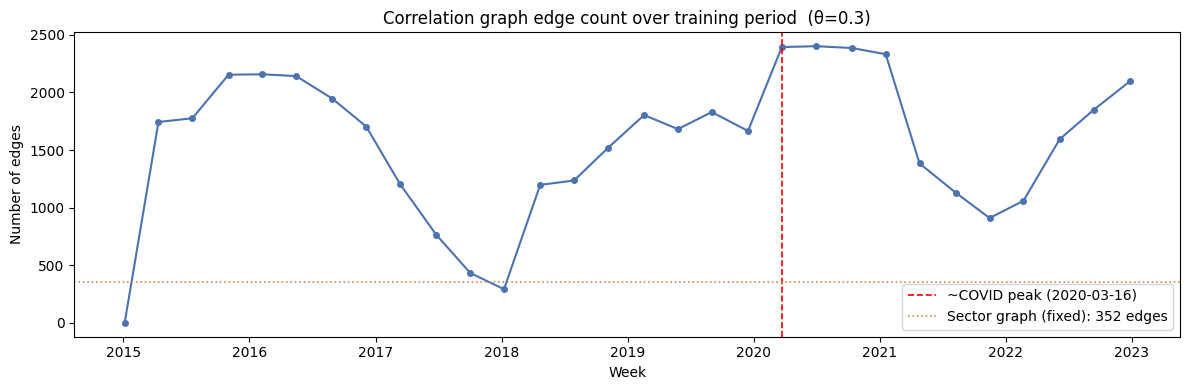

Min edges: 0   Max edges: 2,402   Ratio: 2402.0x


In [9]:
train_weeks_sorted = (
    splits.loc[splits["split"] == "train", "week"]
    .sort_values()
    .reset_index(drop=True)
)
sample_indices = np.linspace(0, len(train_weeks_sorted) - 1, 30, dtype=int)
sampled_weeks  = train_weeks_sorted.iloc[sample_indices]

corr_edge_counts = []
for week in sampled_weeks:
    ei = build_correlation_graph(log_returns, week, config.CORR_LOOKBACK_DAYS, config.CORR_THRESHOLD)
    corr_edge_counts.append(ei.shape[1])

covid_approx = pd.Timestamp("2020-03-16")
closest_covid_i = int(np.argmin(np.abs(sampled_weeks.values - np.datetime64(covid_approx))))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pd.to_datetime(sampled_weeks.values), corr_edge_counts,
        marker="o", markersize=4, linewidth=1.5, color="#4C72B0")
ax.axvline(pd.to_datetime(sampled_weeks.values[closest_covid_i]),
           color="red", linestyle="--", linewidth=1.2, label="~COVID peak (2020-03-16)")
ax.axhline(sector_edge_index.shape[1], color="#DD8452", linestyle=":",
           linewidth=1.2, label=f"Sector graph (fixed): {sector_edge_index.shape[1]:,} edges")
ax.set_xlabel("Week")
ax.set_ylabel("Number of edges")
ax.set_title(f"Correlation graph edge count over training period  (θ={config.CORR_THRESHOLD})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min edges: {min(corr_edge_counts):,}   Max edges: {max(corr_edge_counts):,}"
      f"   Ratio: {max(corr_edge_counts) / max(1, min(corr_edge_counts)):.1f}x")

### Plot 4: Granger directionality verification

Repeats the 3.4 check on the actual `GNNModel` class (not a toy graph).
Every bar must be non-zero: if `SAGEConv` were symmetrizing edges internally,
reversing them would produce identical outputs and all bars would be zero.

Directionality confirmed.
  Max  |diff|: 0.0755
  Mean |diff|: 0.0183
  Stocks with diff > 0: 50 / 50


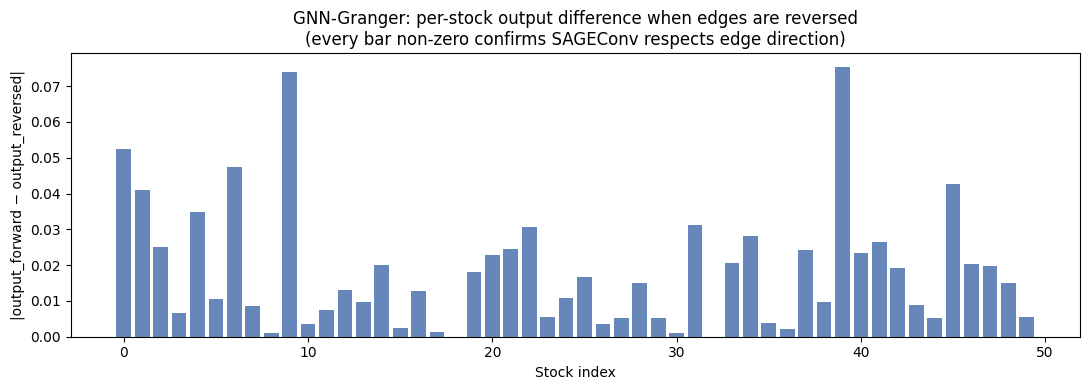

In [10]:
granger_reversed = granger_edge_index[[1, 0]]

gnn_test.eval()
with torch.no_grad():
    out_forward  = gnn_test(features_t, granger_edge_index.to(device))
    out_reversed = gnn_test(features_t, granger_reversed.to(device))

diff = (out_forward - out_reversed).abs().cpu().numpy()
assert not torch.allclose(out_forward, out_reversed), \
    "FAIL: SAGEConv is symmetrizing edges — directionality not working"

print(f"Directionality confirmed.")
print(f"  Max  |diff|: {diff.max():.4f}")
print(f"  Mean |diff|: {diff.mean():.4f}")
print(f"  Stocks with diff > 0: {(diff > 0).sum()} / {len(diff)}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(n_stocks), diff, width=0.8, color="#4C72B0", edgecolor="none", alpha=0.85)
ax.set_xlabel("Stock index")
ax.set_ylabel("|output_forward − output_reversed|")
ax.set_title(
    "GNN-Granger: per-stock output difference when edges are reversed\n"
    "(every bar non-zero confirms SAGEConv respects edge direction)"
)
plt.tight_layout()
plt.show()

### Plot 5: GNN output vs actual RV (random initialization)

At random init the GNN predictions carry no signal; Pearson r should be near zero.
HAR predictions (red ×) are shown on the same axes as a reference: HAR r should be
strongly positive, making the contrast clear.

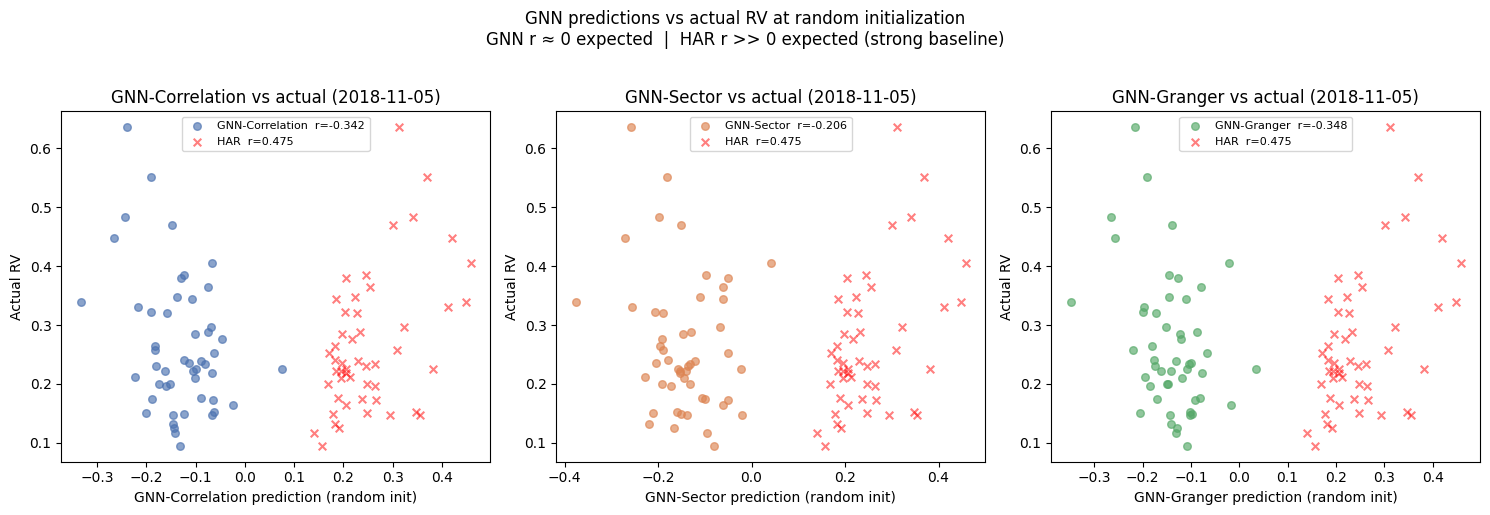

In [11]:
# HAR predictions for the sample week (single-week inference)
X_sample = {
    t: np.array([[rv_1w.loc[sample_week, t],
                  rv_4w.loc[sample_week, t],
                  rv_13w.loc[sample_week, t]]])
    for t in tickers
}
har_sample_preds = har.predict(X_sample)
har_sample_arr   = np.array([har_sample_preds[t][0] for t in tickers])
har_r            = np.corrcoef(har_sample_arr, actual_rv)[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, out, color) in zip(axes, graph_data):
    preds = out.cpu().numpy()
    r     = np.corrcoef(preds, actual_rv)[0, 1]
    ax.scatter(preds, actual_rv, alpha=0.65, s=30, color=color,
               label=f"GNN-{name}  r={r:.3f}")
    ax.scatter(har_sample_arr, actual_rv, alpha=0.5, s=30, marker="x",
               color="red", label=f"HAR  r={har_r:.3f}")
    ax.set_xlabel(f"GNN-{name} prediction (random init)")
    ax.set_ylabel("Actual RV")
    ax.set_title(f"GNN-{name} vs actual ({sample_week.date()})")
    ax.legend(fontsize=8)

plt.suptitle(
    "GNN predictions vs actual RV at random initialization\n"
    "GNN r ≈ 0 expected  |  HAR r >> 0 expected (strong baseline)",
    y=1.02
)
plt.tight_layout()
plt.show()

### GNN-Correlation — Threshold Ablation

Train GNN-Correlation with θ ∈ {0.3, 0.5, 0.7}. Each run uses identical architecture,
seeds, and hyperparameters. The threshold with the lowest validation MSE is selected
and its checkpoint is copied to `gnn_corr_best.pt`.

In [12]:
_ckpt_path    = Path(config.CHECKPOINTS_DIR) / "gnn_corr_best.pt"
_ablation_path = Path(config.DATA_RESULTS_DIR) / "corr_threshold_ablation.json"

if _ckpt_path.exists() and _ablation_path.exists():
    print("gnn_corr_best.pt and corr_threshold_ablation.json found — skipping training.")
    _abl_data = json.load(open(_ablation_path))
    ablation  = {float(k): v for k, v in _abl_data["val_mse_by_threshold"].items()}
    print(f"Best θ={_abl_data['best_threshold']}  val MSE={_abl_data['best_val_mse']:.6f}")
else:
    ablation = train_gnn_corr_ablation(
        features=features_3d,
        target=target_arr,
        week_index=target.index,
        log_returns=log_returns,
        splits=splits,
        device=device,
    )

gnn_corr_best.pt and corr_threshold_ablation.json found — skipping training.
Best θ=0.3  val MSE=0.014658


In [13]:
ablation_data = json.load(open(Path(config.DATA_RESULTS_DIR) / "corr_threshold_ablation.json"))

print(f"{'θ':>6}  {'Val MSE':>12}  {'Selected':>8}")
print("-" * 32)
for theta_str, mse in ablation_data["val_mse_by_threshold"].items():
    marker = "<-- best" if float(theta_str) == ablation_data["best_threshold"] else ""
    print(f"{float(theta_str):>6.1f}  {mse:>12.6f}  {marker}")
print()
print(f"Best threshold : θ = {ablation_data['best_threshold']}")
print(f"Best val MSE   : {ablation_data['best_val_mse']:.6f}")
print(f"Checkpoint     : gnn_corr_best.pt")

     θ       Val MSE  Selected
--------------------------------
   0.3      0.014658  <-- best
   0.5      0.016154  
   0.7      0.015264  

Best threshold : θ = 0.3
Best val MSE   : 0.014658
Checkpoint     : gnn_corr_best.pt


### GNN-Sector Training

Train GNN-Sector using annual point-in-time GICS sector graphs. All stocks sharing the same sector at the start of the calendar year are connected. The graph updates once per year rather than weekly, so training is faster than GNN-Correlation. Architecture and hyperparameters are identical to Task 4.4.

In [14]:
from src.train import train_gnn_sector, predict_gnn_val
from src.graphs import build_all_sector_graphs

# Pre-build sector graphs for all years in the dataset
# sector_history is already loaded in the setup cell above
sector_graphs_dict = build_all_sector_graphs(
    tickers=tickers,
    sector_history=sector_history,
    years=range(2015, 2026),
)

print(f"\nBuilt sector graphs for {len(sector_graphs_dict)} years:")
for year in sorted(sector_graphs_dict):
    print(f"  {year}: {sector_graphs_dict[year].shape[1]:,} edges")

Saved 3968 total edges across 11 years to C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\graphs\sector_edges_by_year.parquet

Built sector graphs for 11 years:
  2015: 400 edges
  2016: 400 edges
  2017: 352 edges
  2018: 352 edges
  2019: 352 edges
  2020: 352 edges
  2021: 352 edges
  2022: 352 edges
  2023: 352 edges
  2024: 352 edges
  2025: 352 edges


In [15]:
_ckpt_path = Path(config.CHECKPOINTS_DIR) / "gnn_sector_best.pt"

if _ckpt_path.exists():
    print("gnn_sector_best.pt found — skipping training.")
    gnn_sector = GNNModel(in_channels=n_feats).to(device)
    gnn_sector.load_state_dict(torch.load(_ckpt_path, map_location=device, weights_only=True))
    _loss_data      = json.load(open(Path(config.DATA_RESULTS_DIR) / "gnn_sector_val_loss.json"))
    sector_val_loss = _loss_data["val_loss"]
    print(f"Best val MSE: {_loss_data['best_val_loss']:.6f}")
else:
    gnn_sector, sector_val_loss = train_gnn_sector(
        features=features_3d,
        target=target_arr,
        week_index=target.index,
        sector_graphs=sector_graphs_dict,
        splits=splits,
        device=device,
    )
    print(f"\nTraining complete. Best checkpoint: gnn_sector_best.pt")

gnn_sector_best.pt found — skipping training.
Best val MSE: 0.015124


In [16]:
# Val MSE comparison: GNN-Sector vs GNN-Correlation
sector_loss_data = json.load(open(Path(config.DATA_RESULTS_DIR) / "gnn_sector_val_loss.json"))
corr_data        = json.load(open(Path(config.DATA_RESULTS_DIR) / "corr_threshold_ablation.json"))

sector_mse = sector_loss_data["best_val_loss"]
corr_mse   = corr_data["best_val_mse"]
best_theta = corr_data["best_threshold"]
diff_pct   = (sector_mse - corr_mse) / corr_mse * 100

print(f"{'Model':<28}  {'Best Val MSE':>12}  {'vs GNN-Corr':>12}")
print("-" * 56)
print(f"{'GNN-Correlation (θ=' + str(best_theta) + ')':<28}  {corr_mse:>12.6f}  {'(reference)':>12}")
print(f"{'GNN-Sector':<28}  {sector_mse:>12.6f}  {diff_pct:>+11.2f}%")
print()
winner = "GNN-Sector" if sector_mse < corr_mse else f"GNN-Correlation (θ={best_theta})"
print(f"Lower val MSE: {winner}")

Model                         Best Val MSE   vs GNN-Corr
--------------------------------------------------------
GNN-Correlation (θ=0.3)           0.014658   (reference)
GNN-Sector                        0.015124        +3.18%

Lower val MSE: GNN-Correlation (θ=0.3)


In [17]:
# Load best sector checkpoint and generate val-set predictions for sector breakdown
ckpt_dir = Path(config.CHECKPOINTS_DIR)
model_sector_eval = GNNModel(in_channels=n_feats).to(device)
model_sector_eval.load_state_dict(
    torch.load(ckpt_dir / "gnn_sector_best.pt", map_location=device, weights_only=True)
)

sector_edge_fn = lambda week: sector_graphs_dict[week.year]

val_preds_sector = predict_gnn_val(
    model=model_sector_eval,
    features=features_3d,
    target=target_arr,
    week_index=target.index,
    edge_index_fn=sector_edge_fn,
    splits=splits,
    tickers=tickers,
    device=device,
)
val_target_sector = pd.DataFrame(
    target_arr, index=target.index, columns=tickers
).loc[val_preds_sector.index]

print(f"Val predictions: {val_preds_sector.shape}  (weeks x stocks)")
print(f"Val targets:     {val_target_sector.shape}")

Val predictions: (52, 50)  (weeks x stocks)
Val targets:     (52, 50)


In [18]:
# Per-sector val MSE breakdown for GNN-Sector
# Uses 2023 point-in-time sector assignments (val year)
sector_map_val = {t: sector_history.get(t, {}).get("2023") for t in tickers}
all_sectors    = sorted(s for s in set(sector_map_val.values()) if s is not None)

sector_mse_rows = []
for sector in all_sectors:
    cols = [t for t in tickers if sector_map_val.get(t) == sector]
    if not cols:
        continue
    preds_s   = val_preds_sector[cols].values
    targets_s = val_target_sector[cols].values
    sector_mse_rows.append((sector, len(cols), float(np.mean((preds_s - targets_s) ** 2))))

sector_mse_rows.sort(key=lambda x: x[2], reverse=True)
print(f"GNN-Sector val MSE by GICS sector (2023, highest to lowest):")
print(f"{'Sector':<35}  {'Stocks':>6}  {'Val MSE':>10}")
print("-" * 57)
for sec, n, mse in sector_mse_rows:
    print(f"{sec:<35}  {n:>6}  {mse:>10.6f}")

GNN-Sector val MSE by GICS sector (2023, highest to lowest):
Sector                               Stocks     Val MSE
---------------------------------------------------------
Energy                                    1    0.039915
Basic Materials                           1    0.028735
Utilities                                 3    0.018918
Consumer Cyclical                         7    0.017108
Technology                               10    0.015105
Healthcare                                9    0.013607
Financial Services                       12    0.013117
Consumer Defensive                        2    0.011779
Industrials                               3    0.011390
Real Estate                               2    0.011191


### GNN-Granger Training

Train GNN-Granger using the static directed Granger causality graph computed in Task 3.3.
The edge index is fixed for all time steps. `build_granger_graph()` reads the saved
p-value matrix and applies multiple-comparison correction without re-running any tests.
If the checkpoint exists, training is skipped and the saved model is loaded directly.

In [19]:
from src.train import train_gnn_granger
from src.graphs import build_granger_graph

# Load static Granger graph from saved parquet (no recomputation of p-values)
granger_ei, correction_used = build_granger_graph(tickers)
print(f"Granger edges: {granger_ei.shape[1]:,}  |  Correction: {correction_used}")

_ckpt_path = Path(config.CHECKPOINTS_DIR) / "gnn_granger_best.pt"

if _ckpt_path.exists():
    print("gnn_granger_best.pt found — skipping training.")
    gnn_granger = GNNModel(in_channels=n_feats).to(device)
    gnn_granger.load_state_dict(
        torch.load(_ckpt_path, map_location=device, weights_only=True)
    )
    _loss_data = json.load(
        open(Path(config.DATA_RESULTS_DIR) / "gnn_granger_val_loss.json")
    )
    granger_val_loss = _loss_data["val_loss"]
    print(f"Best val MSE: {_loss_data['best_val_loss']:.6f}")
else:
    gnn_granger, granger_val_loss = train_gnn_granger(
        features=features_3d,
        target=target_arr,
        week_index=target.index,
        granger_edge_index=granger_ei,
        splits=splits,
        device=device,
    )
    print(f"\nTraining complete. Checkpoint: gnn_granger_best.pt")

Bonferroni yielded 379 edges (< GRANGER_MIN_EDGES=500). Falling back to Benjamini-Hochberg FDR.
Correction: bh  |  Edges: 1,443 / 2,450 pairs
Saved 1,443 directed edges -> C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\graphs\granger_edges.parquet
Granger edges: 1,443  |  Correction: bh
gnn_granger_best.pt found — skipping training.
Best val MSE: 0.017656


In [20]:
granger_loss_data = json.load(
    open(Path(config.DATA_RESULTS_DIR) / "gnn_granger_val_loss.json")
)
granger_mse = granger_loss_data["best_val_loss"]

print(f"Correction method : {correction_used}")
print(f"Granger edges     : {granger_ei.shape[1]:,}")
print()
print(f"{'Model':<30}  {'Best Val MSE':>12}")
print("-" * 46)
print(f"{'GNN-Correlation (θ=' + str(corr_data['best_threshold']) + ')':<30}  {corr_mse:>12.6f}")
print(f"{'GNN-Sector':<30}  {sector_mse:>12.6f}")
print(f"{'GNN-Granger':<30}  {granger_mse:>12.6f}")
print()
best_gnn = min(
    [("GNN-Correlation", corr_mse), ("GNN-Sector", sector_mse), ("GNN-Granger", granger_mse)],
    key=lambda x: x[1],
)
print(f"Best GNN variant: {best_gnn[0]}  val MSE={best_gnn[1]:.6f}")

Correction method : bh
Granger edges     : 1,443

Model                           Best Val MSE
----------------------------------------------
GNN-Correlation (θ=0.3)             0.014658
GNN-Sector                          0.015124
GNN-Granger                         0.017656

Best GNN variant: GNN-Correlation  val MSE=0.014658


### Validation Summary and Go/No-Go Checkpoint

All six models ranked by validation MSE (2023, dev universe).
The gate: at least one GNN variant must beat HAR per-stock on val MSE before proceeding to test evaluation.

In [21]:
from src.evaluate import compile_validation_summary

ranked_table, go_nogo = compile_validation_summary(
    features=features_3d,
    target=target_arr,
    week_index=target.index,
    splits=splits,
    tickers=tickers,
    log_returns=log_returns,
    sector_graphs=sector_graphs_dict,
    granger_edge_index=granger_edge_index,
    device=device,
)

print(f"Decision: {go_nogo}")
print(f"(Dev universe: {config.DEV_UNIVERSE_SIZE} stocks -- not final numbers)\n")
print(ranked_table.to_string(float_format=lambda x: f"{x:.6f}"))
print(f"\nSaved: {Path(config.DATA_RESULTS_DIR) / 'validation_summary.json'}")

Decision: GO
(Dev universe: 50 stocks -- not final numbers)

                         rank      mse      mae        r2
model                                                    
GNN-Correlation (θ=0.3)     1 0.014668 0.088946  0.066081
GNN-Sector                  2 0.015124 0.088086  0.037038
LSTM                        3 0.015686 0.091485  0.001245
HAR pooled                  4 0.015718 0.091020 -0.000783
HAR per-stock               5 0.015978 0.092246 -0.017381
GNN-Granger                 6 0.017400 0.104526 -0.107923

Saved: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\validation_summary.json
